# 2004年大庆中考分数分布的正态拟合

对于大庆市的中考情况，我们有两个来源

1. 教育局对整体的录取名册的公布，详见：[https://web.archive.org/web/20040714041728/http://202.97.254.98:80/](https://web.archive.org/web/20040714041728/http://202.97.254.98:80/)
2. 铁人中学2007年时对2004年中考录取情况的总结，详见：[https://web.archive.org/web/20070705233231/http://www.trzx.cn:80/zhshxch/zhk04.htm](https://web.archive.org/web/20070705233231/http://www.trzx.cn:80/zhshxch/zhk04.htm)

二者信息基本一致，读者可以逐条验证。

我们的目标是找一条正态曲线 μ、σ，使它预测的「≥ 某分数的人数」与实测人数最接近

最接近的那一条就是 μ = 550.8、σ = 33.7，四舍五入为 N(551, 34²)。

> 注意：μ = 551 **不是**全市平均分。我们只拟合了 607 分以上的 4.5%，它只是「这段尾巴最像哪条正态曲线」的数学中心。

## 1 读数据

只用一张表：`2004年大庆市内中考三校分段录取对照表.csv`（铁人中学网站《2004 年市内中考各校录取情况》，已与各校录取名册逐条核验）。
每行一个分数门槛，「名册核验_全市」= 全市该分数及以上的人数。全市考生总数 N = 21500（同一来源）。

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import least_squares
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Hiragino Sans GB', 'Heiti TC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 在 content/kao 里运行，或从仓库根目录运行均可
CSV = '2004年大庆市内中考三校分段录取对照表.csv'
path = next(p for p in [Path(CSV), Path('content/kao')/CSV] if p.exists())
df = pd.read_csv(path, encoding='utf-8-sig').sort_values('分数门槛')

N = 21500                                   # 全市考生数
s = df['分数门槛'].to_numpy()                # 分数门槛
c = df['名册核验_全市'].to_numpy()            # 全市 ≥ 该分的人数
anchors = pd.DataFrame({'分数 ≥': s, '全市累计人数': c, '占全市 %': (100*c/N).round(2)}).set_index('分数 ≥')
print(f'{len(anchors)} 个锚点，分数范围 {s.min()}–{s.max()}')
anchors.T

21 个锚点，分数范围 607–650


分数 ≥,607,610,615,620,625,630,631,632,633,634,...,636,637,638,639,640,641,643,644,645,650
全市累计人数,976.00,856.00,661.00,479.00,328.00,219.00,188.00,175.00,161.00,141.00,...,115.00,99.00,88.00,72.00,60.00,51.00,39.00,31.00,26.00,8.00
占全市 %,4.54,3.98,3.07,2.23,1.53,1.02,0.87,0.81,0.75,0.66,...,0.53,0.46,0.41,0.33,0.28,0.24,0.18,0.14,0.12,0.04


## 2 原理：正态曲线给出什么预测？

如果全市分数服从 N(μ, σ²)，那么分数 ≥ x 的人数应当是

$$\text{人数}(x) = N \cdot \bigl[\,1-\Phi\!\bigl(\tfrac{x-\mu}{\sigma}\bigr)\bigr]$$

其中 Φ 是标准正态分布函数。拟合 = 选 (μ, σ)，让这个预测与上表 21 个实测人数的**平方误差之和最小**（最小二乘）。

In [2]:
def predict(x, mu, sig):
    return N * norm.sf((x - mu) / sig)

def fit(mask):
    r = least_squares(lambda p: predict(s[mask], *p) - c[mask], x0=[550, 30])
    mu, sig = r.x
    pred = predict(s[mask], mu, sig)
    # 累计人数上的 R²
    r2 = 1 - ((c[mask]-pred)**2).sum() / ((c[mask]-c[mask].mean())**2).sum()
    return mu, sig, r2

all_  = np.ones_like(s, bool)
lower = (s >= 610) & (s <= 635)    # 下段
upper = s >= 635                   # 上段

rows = []
for name, m in [('单段（全部 607–650，21 点）', all_), ('下段（610–635）', lower), ('上段（635–650）', upper)]:
    mu, sig, r2 = fit(m)
    rows.append({'拟合': name, '锚点数': int(m.sum()), 'μ': round(mu, 1), 'σ': round(sig, 1), 'R²(累计)': round(r2, 3)})
res = pd.DataFrame(rows)
mu1, sig1, _ = fit(all_)
mu_a, sig_a, _ = fit(lower)
mu_b, sig_b, _ = fit(upper)
res

,拟合,锚点数,μ,σ,R²(累计)
0,单段（全部 607–650，21 点）,21,550.8,33.7,0.990
1,下段（610–635）,10,550.6,34.1,0.995
2,上段（635–650）,11,587.0,19.2,0.997


第一行就是页面标题里的 **N(551, 34²)**：μ = 550.8 → 551，σ = 33.7 → 34。

下面画图：左边是「实测 vs 拟合」的累计人数，中间是 5 分一档的频数，右边是 Q-Q 图（拟合是否是直线）。

## 3 出图

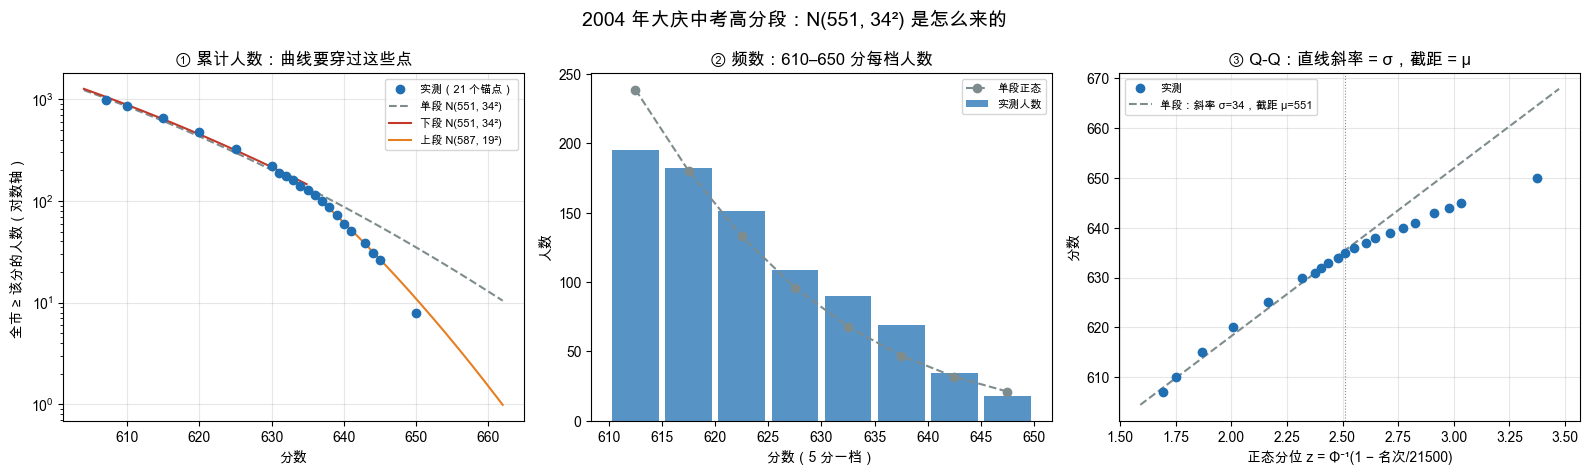

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
xs = np.linspace(604, 662, 300)
BLUE, RED, GREY = '#1f6fb2', '#c0392b', '#7f8c8d'

# ① 累计人数（对数轴）：每个点 = 全市有多少人 ≥ 该分
a = ax[0]
a.scatter(s, c, color=BLUE, zorder=3, label='实测（21 个锚点）')
a.plot(xs, predict(xs, mu1, sig1), '--', color=GREY, label=f'单段 N({mu1:.0f}, {sig1:.0f}²)')
a.plot(xs[xs <= 635], predict(xs[xs <= 635], mu_a, sig_a), color=RED, label=f'下段 N({mu_a:.0f}, {sig_a:.0f}²)')
a.plot(xs[xs >= 635], predict(xs[xs >= 635], mu_b, sig_b), color='#e67e22', label=f'上段 N({mu_b:.0f}, {sig_b:.0f}²)')
a.set_yscale('log'); a.set_xlabel('分数'); a.set_ylabel('全市 ≥ 该分的人数（对数轴）')
a.set_title('① 累计人数：曲线要穿过这些点'); a.legend(fontsize=8); a.grid(alpha=.3)

# ② 5 分一档的频数 = 相邻累计相减；曲线 = 正态预测的同一档人数
a = ax[1]
edges = np.array([610, 615, 620, 625, 630, 635, 640, 645, 650])
cum = dict(zip(s, c))
cnt = np.array([cum[lo] - cum[hi] for lo, hi in zip(edges[:-1], edges[1:])])
mid = (edges[:-1] + edges[1:]) / 2
a.bar(mid, cnt, width=4.4, color=BLUE, alpha=.75, label='实测人数')
a.plot(mid, predict(edges[:-1], mu1, sig1) - predict(edges[1:], mu1, sig1), 'o--', color=GREY, label='单段正态')
a.set_xlabel('分数（5 分一档）'); a.set_ylabel('人数'); a.set_title('② 频数：610–650 分每档人数'); a.legend(fontsize=8)

# ③ Q-Q：横轴 z = 正态分位（越大名次越靠前），纵轴 = 实测分数。点落在直线上 = 像正态；斜率 = σ，z=0 处截距 = μ
a = ax[2]
z = norm.isf(c / N)
a.scatter(z, s, color=BLUE, zorder=3, label='实测')
zz = np.linspace(z.min() - .1, z.max() + .1, 50)
a.plot(zz, mu1 + sig1 * zz, '--', color=GREY, label=f'单段：斜率 σ={sig1:.0f}，截距 μ={mu1:.0f}')
a.axvline(norm.isf(129 / N), color=GREY, lw=.8, ls=':')
a.set_xlabel('正态分位 z = Φ⁻¹(1 − 名次/21500)'); a.set_ylabel('分数')
a.set_title('③ Q-Q：直线斜率 = σ，截距 = μ'); a.legend(fontsize=8); a.grid(alpha=.3)

fig.suptitle('2004 年大庆中考高分段：N(551, 34²) 是怎么来的', fontsize=14)
fig.tight_layout()
fig.savefig('2004年大庆中考单段正态N551-34的来源.png', dpi=150)
plt.show()

## 4 怎么读这张图

- **① 累计人数**：蓝点是实测，灰虚线是单段正态。在 610–635 之间几乎穿过每个点；到了 640 以上，点开始落到曲线**下面**。
- **② 频数**：610–635 各档，预测与实测大体吻合（最低一档 610–615 预测 239、实测 195，偏差最大）；640 分以上实测明显少于预测——顶端「被压扁」。
- **③ Q-Q**：点不是一条直线，而是在 z≈2.5（≈635 分）处折弯、变陡变缓。斜率 = σ，所以：下段 σ≈34，上段 σ≈19。
  这就是页面里「两段」的由来：**单段 N(551, 34²) 管得住 610–635，管不了 635 以上。**

## 5 另一半：635 分以上为什么换成 N(587, 19²)？

**做法完全一样**，只是换一批锚点：用 635–650 分的 11 个累计人数，再做一次最小二乘，得到 μ = 587.0、σ = 19.2（见第 2 节的表格）。
所以 N(587, 19²) 的来源和 N(551, 34²) 的来源相同，区别只在于**拟合的分数范围**。

真正需要回答的是两个问题：① 为什么要在 635 处断开？② 断开之后真的更好吗？先回答②，再回答①。

### 5.1 更好吗？——用同一把尺子比较

为了让比较公平，这里把全部 21 个锚点都拿来评分，用「泊松加权误差」

$$\chi^2=\sum \frac{(\text{实测}-\text{预测})^2}{\text{预测}}$$

它给人数少的顶端点和人数多的底端点以合理的权重（人数越少，同样的绝对误差越严重）。数值越小越贴近。

In [4]:
S, Cum = s, c      # 21 个锚点

def chi2(x, obs, mu, sig):
    e = predict(x, mu, sig)
    return (((obs - e) ** 2) / np.maximum(e, .5)).sum()

# 两段模型：≤635 用下段，>635 用上段
def two_seg(x):
    return np.where(x <= 635, predict(x, mu_a, sig_a), predict(x, mu_b, sig_b))

lo, hi = S <= 635, S > 635
rows = [
  ['单段 N(551, 34²)', chi2(S[lo], Cum[lo], mu1, sig1), chi2(S[hi], Cum[hi], mu1, sig1)],
  ['两段 N(551, 34²) + N(587, 19²)',
   chi2(S[lo], Cum[lo], mu_a, sig_a), chi2(S[hi], Cum[hi], mu_b, sig_b)],
]
tab = pd.DataFrame(rows, columns=['模型', '607–635 误差', '636–650 误差'])
tab['合计'] = tab.iloc[:, 1] + tab.iloc[:, 2]
tab.round(1)

,模型,607–635 误差,636–650 误差,合计
0,"单段 N(551, 34²)",16.7,93.9,110.6
1,"两段 N(551, 34²) + N(587, 19²)",15.1,1.2,16.3


单段在 607–635 上本来就不错，两段只是略微改善；**真正的差别在 636 分以上**——单段的误差大得多。
再看最顶端：650 分及以上全市只有 8 人。两个模型各自预测多少人？

In [5]:
tip = pd.DataFrame({'分数 ≥': [640, 643, 645, 650]})
tip['实测人数'] = [int(cum[x]) for x in tip['分数 ≥']]
tip['单段 N(551,34²)'] = predict(tip['分数 ≥'], mu1, sig1).round(1)
tip['上段 N(587,19²)'] = predict(tip['分数 ≥'], mu_b, sig_b).round(1)
tip

,分数 ≥,实测人数,"单段 N(551,34²)","上段 N(587,19²)"
0,640,60,87.6,61.3
1,643,39,67.1,37.6
2,645,26,56.0,26.7
3,650,8,35.0,10.9


单段预测「650 分及以上」应有 35 人，实际只有 8 人；上段 N(587, 19²) 预测 ≈11 人，接近得多。
**单段把顶端高估了数倍**，这就是最直观的「更好」。

### 5.2 为什么偏偏是 635？——扫描接缝位置

不预设 635：让接缝 m 取每个可用的锚点（两侧都至少留 4 个点），把 [607, m] 和 [m, 650] 各拟合一次，看总误差在哪里最小。

In [6]:
def fit_range(mask):
    r = least_squares(lambda p: predict(S[mask], *p) - Cum[mask], x0=[550, 30])
    return r.x

splits = [m for m in S if (S <= m).sum() >= 4 and (S >= m).sum() >= 4]
scan = []
for m in splits:
    pl, ph = fit_range(S <= m), fit_range(S >= m)
    scan.append((m, chi2(S[S <= m], Cum[S <= m], *pl) + chi2(S[S >= m], Cum[S >= m], *ph), pl[1], ph[1]))
scan = pd.DataFrame(scan, columns=['接缝', '总误差', 'σ下', 'σ上']).set_index('接缝')
best = scan['总误差'].idxmin()
print(f'总误差最小的接缝在 {best} 分（σ 下 {scan.loc[best,"σ下"]:.1f} → σ 上 {scan.loc[best,"σ上"]:.1f}）')
print(f'对照：单段（不设接缝）总误差 {chi2(S, Cum, mu1, sig1):.0f}；最佳两段 {scan["总误差"].min():.0f}')
scan.round(1).T

总误差最小的接缝在 630 分（σ 下 38.4 → σ 上 22.9）
对照：单段（不设接缝）总误差 111；最佳两段 14


接缝,620,625,630,631,632,633,634,635,636,637,638,639,640,641,643
总误差,36.7,24.2,13.9,17.0,15.8,15.4,16.9,17.6,19.6,23.3,27.3,34.6,43.9,54.2,64.6
σ下,41.8,39.6,38.4,37.4,36.8,36.4,36.1,35.8,35.5,35.2,35.0,34.8,34.5,34.3,34.1
σ上,28.0,25.8,22.9,22.7,21.6,20.7,20.2,19.2,18.6,18.3,17.9,18.6,18.7,18.1,15.3


总误差的谷底在 630–635 之间（14–18），很平；往两边走明显变差：接缝取 620 是 37，取 643 是 65，单段（相当于完全不断开）是 ≈111。
所以数据支持「折点在 630–635 一带」，而**不能精确到 635**——最低点其实是 630，页面取 635 在平坦的谷底里，只是更整齐。
注意：只用 21 个锚点时，630–635 之间的点又密又相关，所以别把谷底的细微差别当回事。

接缝左右的 σ 从 ≈36 掉到 ≈20——曲线在 635 之后收窄一倍，这就是下图 Q-Q 里那个折点。

### 5.3 出图：为什么两段更好

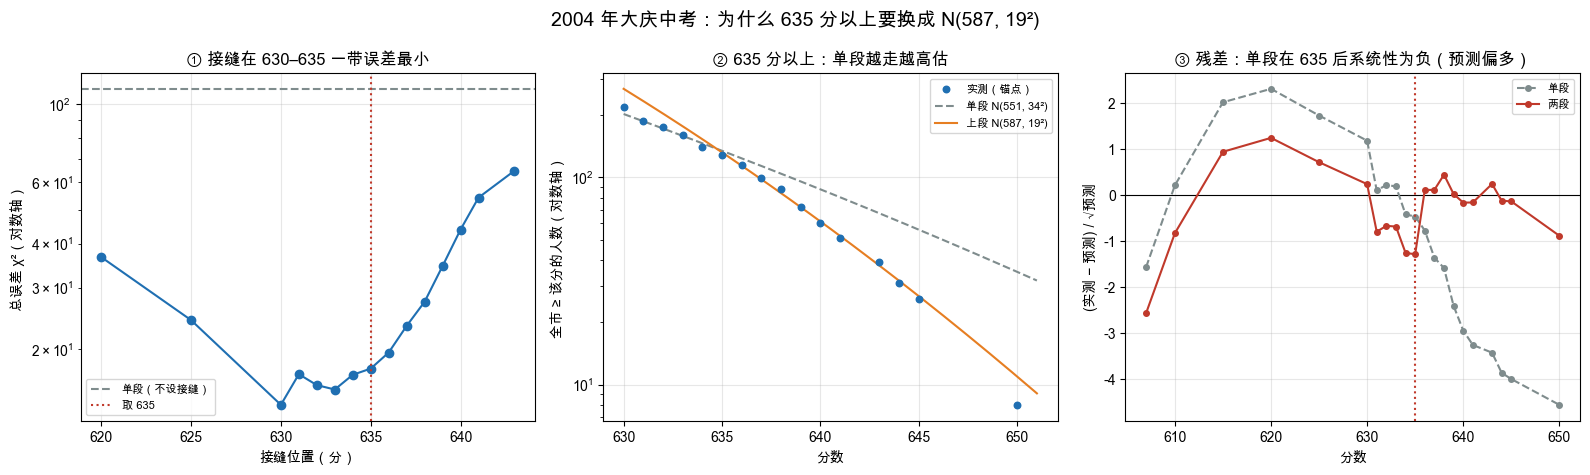

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
BLUE, RED, GREY, ORG = '#1f6fb2', '#c0392b', '#7f8c8d', '#e67e22'

# ① 接缝扫描
a = ax[0]
a.plot(scan.index, scan['总误差'], 'o-', color=BLUE)
a.axhline(chi2(S, Cum, mu1, sig1), ls='--', color=GREY, label='单段（不设接缝）')
a.axvline(635, color=RED, ls=':', label='取 635')
a.set_yscale('log'); a.set_xlabel('接缝位置（分）'); a.set_ylabel('总误差 χ²（对数轴）')
a.set_title('① 接缝在 630–635 一带误差最小'); a.legend(fontsize=8); a.grid(alpha=.3)

# ② 顶端放大：累计人数
a = ax[1]
x = np.linspace(630, 651, 200)
m = S >= 630
a.scatter(S[m], Cum[m], color=BLUE, zorder=3, s=22, label='实测（锚点）')
a.plot(x, predict(x, mu1, sig1), '--', color=GREY, label='单段 N(551, 34²)')
a.plot(x, predict(x, mu_b, sig_b), color=ORG, label='上段 N(587, 19²)')
a.set_yscale('log'); a.set_xlabel('分数'); a.set_ylabel('全市 ≥ 该分的人数（对数轴）')
a.set_title('② 635 分以上：单段越走越高估'); a.legend(fontsize=8); a.grid(alpha=.3)

# ③ 每个锚点的标准化残差 (实测−预测)/√预测
a = ax[2]
e1 = (Cum - predict(S, mu1, sig1)) / np.sqrt(np.maximum(predict(S, mu1, sig1), .5))
e2 = (Cum - two_seg(S)) / np.sqrt(np.maximum(two_seg(S), .5))
a.axhline(0, color='k', lw=.8)
a.plot(S, e1, 'o--', color=GREY, ms=4, label='单段')
a.plot(S, e2, 'o-', color=RED, ms=4, label='两段')
a.axvline(635, color=RED, ls=':')
a.set_xlabel('分数'); a.set_ylabel('(实测 − 预测) / √预测')
a.set_title('③ 残差：单段在 635 后系统性为负（预测偏多）'); a.legend(fontsize=8); a.grid(alpha=.3)

fig.suptitle('2004 年大庆中考：为什么 635 分以上要换成 N(587, 19²)', fontsize=14)
fig.tight_layout()
fig.savefig('2004年大庆中考两段正态N587-19的来源.png', dpi=150)
plt.show()

## 6 为什么 σ 会减半？——一个解释（不是证明）

- **事实**：610–635 的下降速度像 σ≈34 的正态；635 以后下降快得多，像 σ≈19。
- **解释**：这批高分几乎全是三所示范高中（铁人／实验／一中）招进去的尖子，他们已经接近**卷面的天花板**（满分 690）。
  再往上没有那么多分可拿，学生像被挤在一道看不见的墙下，分布的上尾因此被压短——曲线「提前收尾」，σ 变小。
- **边界**：这是对形状的解释，不是用数据直接验证的结论。拟合本身只告诉我们「635 前后需要两种宽度」，
  至于为什么，需要上面这个假设来补；而且上段只有 11 个累计点，σ≈19 的不确定度比下段大。

另外两段在接缝处的预测并不严格相接（635 分处下段给出约 143 人，上段约 134 人，实测 129 人），
所以它是**两张局部的拟合图**，不是一条连续的分布曲线。

## 7 为什么是 N(551, 34²)，而不是别的数？——两个检验

In [8]:
# 检验 1：铁人中学录取线 607 分——曲线的预测与实测差多少？
print(f'607 分：实测 {cum[607]} 人，单段预测 {predict(607, mu1, sig1):.0f} 人')

# 检验 2：换一种拟合方式会怎样？——在 z 空间（Q-Q 图上）直接拟合直线
z = norm.isf(c / N)
sig_z, mu_z = np.polyfit(z, s, 1)
print(f'\nQ-Q 直线拟合：μ={mu_z:.1f}, σ={sig_z:.1f}   （页面里的“备选”拟合）')
print(f'人数空间最小二乘：μ={mu1:.1f}, σ={sig1:.1f}   （页面采用）')

# 两条曲线在各分数的预测人数对比
cmp_ = pd.DataFrame({'分数': [607, 620, 630, 640, 650], })
cmp_['实测'] = [cum[x] for x in cmp_['分数']]
cmp_['人数空间 N(551,34²)'] = predict(cmp_['分数'], mu1, sig1).round(0)
cmp_['Q-Q 直线 N(568,26²)'] = predict(cmp_['分数'], mu_z, sig_z).round(0)
cmp_

607 分：实测 976 人，单段预测 1026 人

Q-Q 直线拟合：μ=567.6, σ=26.1   （页面里的“备选”拟合）
人数空间最小二乘：μ=550.8, σ=33.7   （页面采用）


,分数,实测,"人数空间 N(551,34²)","Q-Q 直线 N(568,26²)"
0,607,976,1026.0,1401.0
1,620,479,431.0,476.0
2,630,219,202.0,178.0
3,640,60,88.0,59.0
4,650,8,35.0,17.0


**为什么页面用人数空间的拟合？** 看上表：Q-Q 直线 N(568, 26²) 把 640–650 的顶端拟得更好，
却在人最多的 607 分处预测 1401 人（实测 976），差了 40%。人数空间的拟合按「人数」加权，**权重自然落在人多的 607–635 段**，
这一段才是数据最可靠、也最多人关心的位置。两种拟合给出的 μ、σ 差异（551/34 vs 568/26）本身就在提醒：**这是局部描述，不是对全体的真值**。

## 8 结论与边界

1. **来源**：21 个「全市 ≥ 某分」的实测累计人数 → 最小二乘 → μ = 550.8, σ = 33.7 → **N(551, 34²)**。
2. **能说**：它在 610–635 分这一段贴合得很好，可以用来估计「某个分数在全市的位置」。
3. **两段更好**：635 分以上用 N(587, 19²)，650 分及以上预测 ≈11 人（实测 8 人），单段给出 35 人；接缝位置经扫描在 630–635 一带误差最小（不能精确到某一分）。
4. **不能说**：
   - μ = 551 不是全市平均分——我们只用了前 4.5%；
   - 635 分以上实测比它预测的少（上限 690 分、卷面天花板压缩了顶端），σ 在这里降到 ≈19；
   - 607 分以下没有可信数据，向低分外推只是推测。